In [10]:
import glob

In [14]:
aia_files = glob.glob('../AIA_samples/*.fits')
len(aia_files), aia_files[:5]

(15,
 ['../AIA_samples/aia.lev15.193A_2011_06_07T06_24_08.19Z.image_lev15.fits',
  '../AIA_samples/aia.lev15.193A_2011_06_07T06_25_46.17Z.image_lev15.fits',
  '../AIA_samples/aia.lev15.193A_2011_06_07T06_26_10.08Z.image_lev15.fits',
  '../AIA_samples/aia.lev15.193A_2011_06_07T06_26_57.86Z.image_lev15.fits',
  '../AIA_samples/aia.lev15.193A_2011_06_07T06_26_33.98Z.image_lev15.fits'])

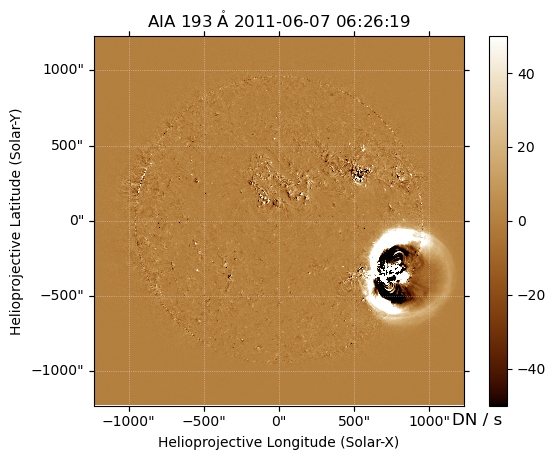

In [22]:
from fits_processing import create_running_diff_maps
import sunpy.map

aia_maps = []
for file in aia_files:
    aia = sunpy.map.Map(file)
    aia_maps.append(aia)

rundiff = create_running_diff_maps(aia_maps)
rundiff[0].peek()

In [174]:
def plot_line(angle_deg=None, length=None, map_obj=None):
    """
    Plot a straight line at an angle in degrees from the solar West.
    """
    angle_rad = np.deg2rad(angle_deg)

    # Define the length of the line (in arcseconds)
    line_length = length * u.arcsec

    # Define the center point of the line (e.g., the center of the map)
    center = map_obj.center

    # Calculate the start and end points of the line
    start_point = SkyCoord(center.Tx, center.Ty, frame=map_obj.coordinate_frame)

    end_point = SkyCoord(center.Tx + line_length * np.cos(angle_rad),
                        center.Ty + line_length * np.sin(angle_rad),
                        frame=map_obj.coordinate_frame)
    
    line = SkyCoord([start_point, end_point])
    return line


def generate_centered_list(center, difference, num_elements):
    """
    Generate a list of numbers centered around a given number with a specified difference
    between consecutive numbers.

    Parameters:
        center (int): The central number around which the list is generated.
        difference (int): The difference between consecutive numbers in the list.
        num_elements (int): The number of elements before and after the central number.

    Returns:
        list: A list of numbers centered around the specified central number.
    """
    return [center + difference * i for i in range(-num_elements, num_elements + 1)]

centered_list = generate_centered_list(337, 3, 6)

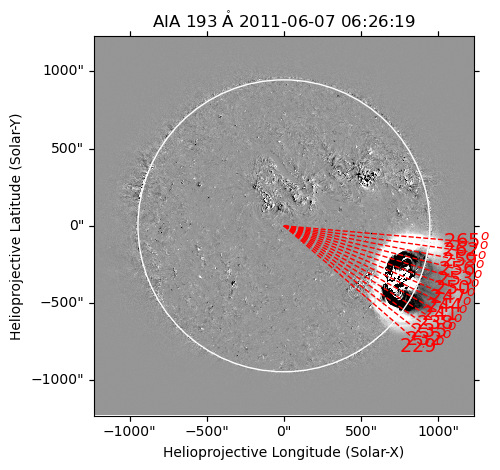

In [175]:
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord

position_angles = []
m = rundiff[0]

# # crop the map
# top_right = SkyCoord(-200*u.arcsec, 1100*u.arcsec, frame=m.coordinate_frame)
# bottom_left = SkyCoord(-2200*u.arcsec, 50*u.arcsec, frame=m.coordinate_frame)
# m_submap = m.submap(bottom_left, top_right=top_right)

fig = plt.figure()
ax  = fig.add_subplot(projection=m)
m.plot(axes=ax, cmap='Greys_r')
m.draw_limb()
ax.grid(False)

for value in centered_list:
    PA_value = value - 90 # rename the angles to be position angles, instead of geometric angles
    position_angles.append(PA_value)
    line = plot_line(angle_deg=value, length=1200, map_obj=m)
    ax.plot_coord(line, color='red', lw=1, ls='--')
    
    # Plot the number at the end of the line
    # Convert SkyCoord to pixel coordinates for plotting text
    line_lon, line_lat = line.Tx, line.Ty
    end_point_pixel = m.world_to_pixel(SkyCoord(line_lon[1], line_lat[1],
                                                        frame=m.coordinate_frame))
    # Display the number at the end point
    ax.text(end_point_pixel.x.value - 20, end_point_pixel.y.value + 5, f'{PA_value}$^o$',
            color='red', fontsize=14, ha='center', va='center')

# ax.set_xlim(left=-150, right=400)
# ax.set_ylim(bottom=650, top=1100)
fig.tight_layout()
plt.show()

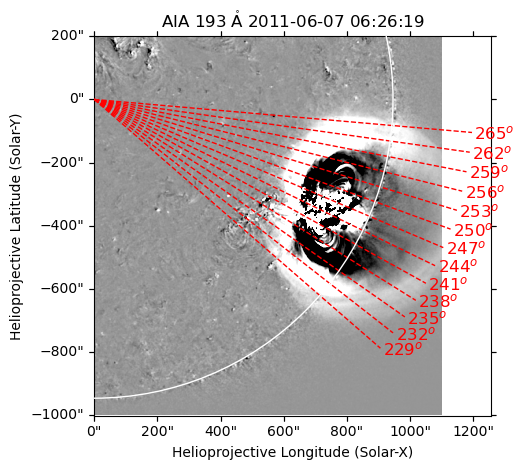

In [176]:
# crop the map
top_right = SkyCoord(1100*u.arcsec, 200*u.arcsec, frame=m.coordinate_frame)
bottom_left = SkyCoord(0*u.arcsec, -1000*u.arcsec, frame=m.coordinate_frame)
m_submap = m.submap(bottom_left, top_right=top_right)

fig = plt.figure()
ax  = fig.add_subplot(projection=m_submap)
m_submap.plot(axes=ax, cmap='Greys_r')
m_submap.draw_limb()
ax.grid(False)

for value in centered_list:
    PA_value = value - 90 # rename the angles to be position angles, instead of geometric angles
    position_angles.append(PA_value)
    line = plot_line(angle_deg=value, length=1200, map_obj=m)
    ax.plot_coord(line, color='red', lw=1, ls='--')
    
    # Plot the number at the end of the line
    # Convert SkyCoord to pixel coordinates for plotting text
    line_lon, line_lat = line.Tx, line.Ty
    end_point_pixel = m_submap.world_to_pixel(SkyCoord(line_lon[1], line_lat[1],
                                                        frame=m_submap.coordinate_frame))
    # Display the number at the end point
    ax.text(end_point_pixel.x.value+120, end_point_pixel.y.value-5, f'{PA_value}$^o$',
            color='red', fontsize=12, ha='center', va='center')

fig.tight_layout()
plt.show()

In [177]:
# Make a dictionary to hold the lists of lists
intensity_dict    = {}
distances_dict    = {}
output_obj        = {}
jmaps_coords_list = {}

# Initialize each key with an empty list
for value in centered_list:
    intensity_dict[f'intensity_{value}deg'] = []
    distances_dict[f'distances_{value}deg'] = []
    output_obj[f'intensity_{value}deg']     = []
    output_obj[f'distances_{value}deg']     = []
    jmaps_coords_list[f'{value}']           = []

output_obj['time']       = []
output_obj['map_obj']    = []
output_obj['instrument'] = []

for i, m in enumerate(rundiff):
    for value in centered_list:
        line = plot_line(angle_deg=value, length=1200, map_obj=m)
        
        # obtain the coordinates of the map pixels that intersect that path
        intensity_coords_slit = sunpy.map.pixelate_coord_path(m, line)
        
        # Create mask to identify valid coordinates
        valid_mask = sunpy.map.contains_coordinate(m, intensity_coords_slit)
        
        # Apply the mask to filter valid coordinates
        valid_coords = intensity_coords_slit[valid_mask]
        
        # Pass those coordinates to extract the values for those map pixels
        intensity_slit = sunpy.map.sample_at_coords(m, valid_coords)
        
        # Calculate the angular separation between the first point and every other coordinate we extracted
        angular_separation_slit = valid_coords.separation(valid_coords[0]).to(u.arcsec)
        
        # Append the values to the lists
        intensity_dict[f'intensity_{value}deg'].append(list(intensity_slit.value))
        distances_dict[f'distances_{value}deg'].append(list(angular_separation_slit.value))
    
    output_obj['time'].append(m.date.iso)
    output_obj['map_obj'].append(m)
    output_obj['instrument'].append(f"AIA {m.meta['wavelnth']}A")

In [178]:
import matplotlib.dates as mdates
import pandas as pd

datenum_arr = [mdates.date2num(pd.Timestamp(str(t))) for t in output_obj['time']]

for value in centered_list:
    intens = np.array(intensity_dict[f'intensity_{value}deg']).T
    height = np.array(distances_dict[f'distances_{value}deg'][0])
    output_obj[f'intensity_{value}deg'].append(intens)
    output_obj[f'distances_{value}deg'].append(height)

In [179]:
list(intensity_dict.keys())

['intensity_319deg',
 'intensity_322deg',
 'intensity_325deg',
 'intensity_328deg',
 'intensity_331deg',
 'intensity_334deg',
 'intensity_337deg',
 'intensity_340deg',
 'intensity_343deg',
 'intensity_346deg',
 'intensity_349deg',
 'intensity_352deg',
 'intensity_355deg']

In [180]:
m.rsun_obs.value # in pix == 1 solar radius

np.float64(945.437069)

In [181]:
def onclick(event):
    """
    This function is called when the mouse is clicked on the figure.
    It adds the x and y coordinates of the click to the coords list.
    """
    global current_trial, text_handle

    if event.button == 1:  # Left mouse button
        xx, yy = event.xdata, event.ydata  # Get the central x and y coordinates
        ax.plot(xx, yy, 'ro', markersize=7)
        plt.draw()

        # Store the coordinates in the current trial's list
        feature_coords_slit[f'trial_{current_trial}'].append((xx, yy))
        
        # Update the text on the plot
        if text_handle:
            text_handle.remove()  # Remove the previous text
        text_handle = ax.text(0.05, 0.95, f"Trial {current_trial + 1}: Captured ({xx:.2f}, {yy:.2f})", 
                              transform=ax.transAxes, fontsize=12, verticalalignment='top', color='pink')
        plt.draw()

    elif event.button == 3:  # Right mouse button
        # Move to the next trial
        current_trial += 1
        if current_trial >= num_repeats:
            fig.canvas.mpl_disconnect(cid)
            plt.close(fig)  # Close the figure window
        else:
            if text_handle:
                text_handle.remove()
            text_handle = ax.text(0.05, 0.95, f"Moving to trial {current_trial + 1}", 
                                  transform=ax.transAxes, fontsize=12, verticalalignment='top', color='cyan')
            plt.draw()

Working on slit: 340 deg.


/var/folders/x2/l9mvx3_j0dq_chfk9knp41780000gp/T/ipykernel_48930/861777719.py:24: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  jmap = ax.pcolormesh(datenum_arr, height, intens, vmin=-1e1, vmax=1e2, cmap='Greys_r')


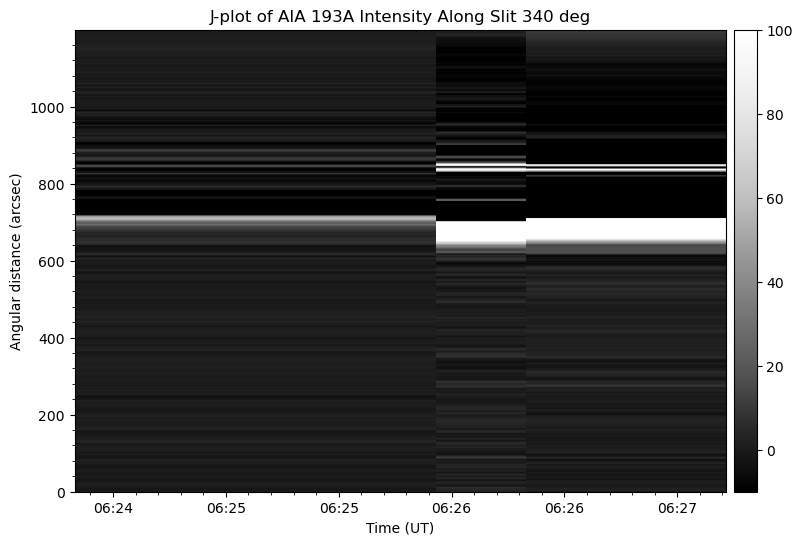

In [182]:
from matplotlib.ticker import AutoMinorLocator

angle = 340

height = output_obj[f'distances_{angle}deg'][0].copy()
intens = output_obj[f'intensity_{angle}deg'][0].copy()

print(f'Working on slit: {angle} deg.')

# Number of repetitions
num_repeats   = 5
current_trial = 0

# Dictionary to store coordinates for each trial
feature_coords_slit = {f'trial_{i}': [] for i in range(num_repeats)}

# Text handle to update on the plot
text_handle = None

# plot the j-map
fig = plt.figure(figsize=[10,6])
ax = fig.add_subplot(111)
plt.ion()
jmap = ax.pcolormesh(datenum_arr, height, intens, vmin=-1e1, vmax=1e2, cmap='Greys_r')
plt.colorbar(jmap, ax=ax, pad=0.01)
ax.set_xlabel('Time (UT)')
ax.set_ylabel('Angular distance (arcsec)')
ax.set_title(f"J-plot of {output_obj['instrument'][0]} Intensity Along Slit {angle} deg")
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_minor_locator(AutoMinorLocator(n=5))
ax.yaxis.set_minor_locator(AutoMinorLocator(n=5))
# ax.set_xlim(left=pd.Timestamp(f"{output_obj['time'][0].split(' ')[0]} 17:10:00"),
#             right=pd.Timestamp(f"{output_obj['time'][0].split(' ')[0]} 17:55:00"))
# ax.set_ylim(bottom=np.ceil(m.rsun_obs.value)) # round up to the nearest integer

# Connect the click event to the onclick function
cid = fig.canvas.mpl_connect('button_press_event', onclick)
plt.show(block=False)
plt.pause(0.001)

# Another Method

In [183]:
def apply_runratio(maps):
    """
    Apply running-ratio image technique on EUV images.
    See: https://iopscience.iop.org/article/10.1088/0004-637X/750/2/134/pdf
        Inputs: list of EUV sunpy maps.
        Output: sequence of run-ratio sunpy maps.
    """
    runratio = [m / prev_m.quantity for m, prev_m in zip(maps[1:], maps[:-1])]
    m_seq_runratio = sunpy.map.Map(runratio, sequence=True)
    
    for m in m_seq_runratio:
        m.data[np.isnan(m.data)] = 1
        m.plot_settings['norm'] = colors.Normalize(vmin=0.5, vmax=1.7)
        m.plot_settings['cmap'] = 'Greys_r'
    
    return m_seq_runratio

In [184]:
runratio = apply_runratio(aia_maps)

/Applications/anaconda3/envs/dias/lib/python3.11/site-packages/astropy/units/quantity.py:659: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Applications/anaconda3/envs/dias/lib/python3.11/site-packages/astropy/units/quantity.py:659: RuntimeWarning: invalid value encountered in multiply
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Applications/anaconda3/envs/dias/lib/python3.11/site-packages/astropy/units/quantity.py:659: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Applications/anaconda3/envs/dias/lib/python3.11/site-packages/astropy/units/quantity.py:659: RuntimeWarning: invalid value encountered in multiply
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Applications/anaconda3/envs/dias/lib/python3.11/site-packages/astropy/units/quantity.py:659: RuntimeWarning: divide by ze

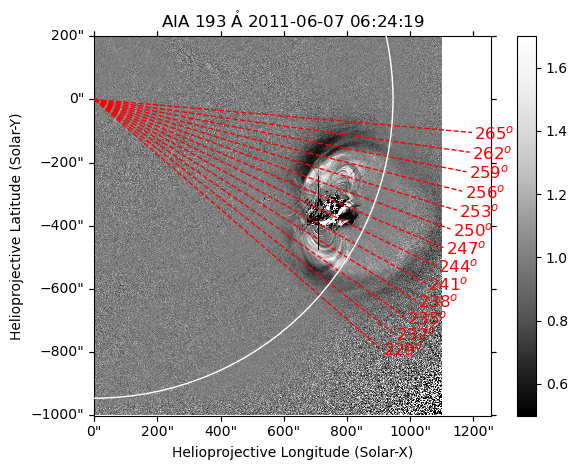

In [185]:
position_angles = []
m = runratio[0]

# crop the map
top_right = SkyCoord(1100*u.arcsec, 200*u.arcsec, frame=m.coordinate_frame)
bottom_left = SkyCoord(0*u.arcsec, -1000*u.arcsec, frame=m.coordinate_frame)
m_submap = m.submap(bottom_left, top_right=top_right)

fig = plt.figure()
ax  = fig.add_subplot(projection=m_submap)
img = m_submap.plot(axes=ax)
plt.colorbar(img, ax=ax, pad=0.05)
m_submap.draw_limb()
ax.grid(False)

for value in centered_list:
    PA_value = value - 90 # rename the angles to be position angles, instead of geometric angles
    position_angles.append(PA_value)
    line = plot_line(angle_deg=value, length=1200, map_obj=m)
    ax.plot_coord(line, color='red', lw=1, ls='--')
    
    # Plot the number at the end of the line
    # Convert SkyCoord to pixel coordinates for plotting text
    line_lon, line_lat = line.Tx, line.Ty
    end_point_pixel = m_submap.world_to_pixel(SkyCoord(line_lon[1], line_lat[1],
                                                        frame=m_submap.coordinate_frame))
    # Display the number at the end point
    ax.text(end_point_pixel.x.value+120, end_point_pixel.y.value-5, f'{PA_value}$^o$',
            color='red', fontsize=12, ha='center', va='center')

fig.tight_layout()
plt.show()

In [190]:
# Make a dictionary to hold the lists of lists
intensity_dict    = {}
distances_dict    = {}
output_obj        = {}
jmaps_coords_list = {}

# Initialize each key with an empty list
for value in centered_list:
    intensity_dict[f'intensity_{value}deg'] = []
    distances_dict[f'distances_{value}deg'] = []
    output_obj[f'intensity_{value}deg']     = []
    output_obj[f'distances_{value}deg']     = []
    jmaps_coords_list[f'{value}']           = []

output_obj['time']       = []
output_obj['map_obj']    = []
output_obj['instrument'] = []

for i, m in enumerate(runratio):
    for value in centered_list:
        line = plot_line(angle_deg=value, length=1200, map_obj=m)
        
        # obtain the coordinates of the map pixels that intersect that path
        intensity_coords_slit = sunpy.map.pixelate_coord_path(m, line)
        
        # Create mask to identify valid coordinates
        valid_mask = sunpy.map.contains_coordinate(m, intensity_coords_slit)
        
        # Apply the mask to filter valid coordinates
        valid_coords = intensity_coords_slit[valid_mask]
        
        # Pass those coordinates to extract the values for those map pixels
        intensity_slit = sunpy.map.sample_at_coords(m, valid_coords)
        
        # Calculate the angular separation between the first point and every other coordinate we extracted
        angular_separation_slit = valid_coords.separation(valid_coords[0]).to(u.arcsec)
        
        # Append the values to the lists
        intensity_dict[f'intensity_{value}deg'].append(list(intensity_slit.value))
        distances_dict[f'distances_{value}deg'].append(list(angular_separation_slit.value))
    
    output_obj['time'].append(m.date.iso)
    output_obj['map_obj'].append(m)
    output_obj['instrument'].append(f"AIA {m.meta['wavelnth']}A")

In [195]:
list(intensity_dict.keys())

['intensity_319deg',
 'intensity_322deg',
 'intensity_325deg',
 'intensity_328deg',
 'intensity_331deg',
 'intensity_334deg',
 'intensity_337deg',
 'intensity_340deg',
 'intensity_343deg',
 'intensity_346deg',
 'intensity_349deg',
 'intensity_352deg',
 'intensity_355deg']

In [196]:
datenum_arr = [mdates.date2num(pd.Timestamp(str(t))) for t in output_obj['time']]

for value in centered_list:
    intens = np.array(intensity_dict[f'intensity_{value}deg']).T
    height = np.array(distances_dict[f'distances_{value}deg'][0])
    output_obj[f'intensity_{value}deg'].append(intens)
    output_obj[f'distances_{value}deg'].append(height)

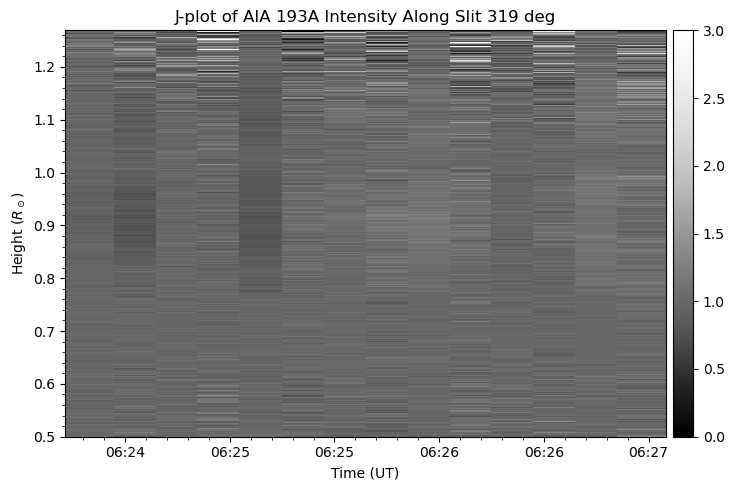

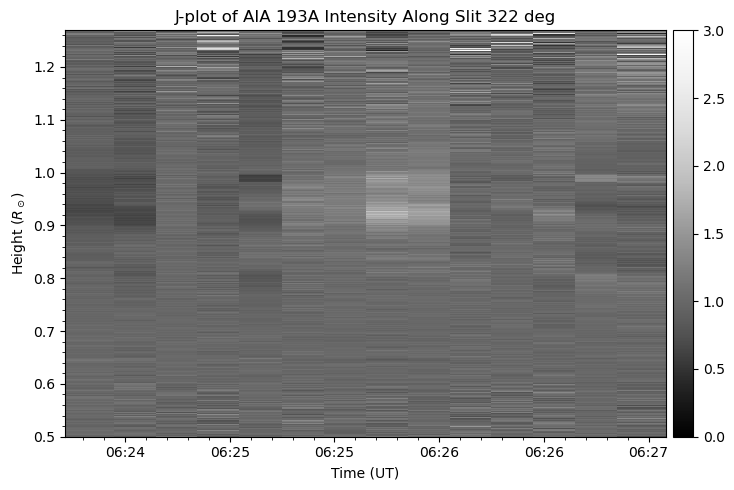

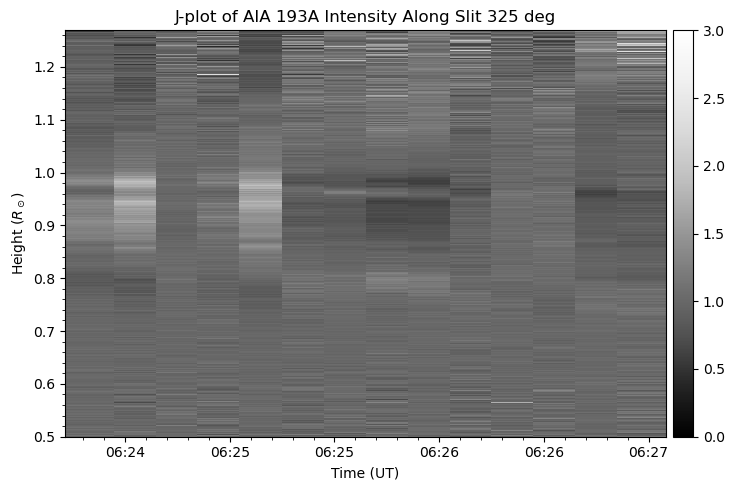

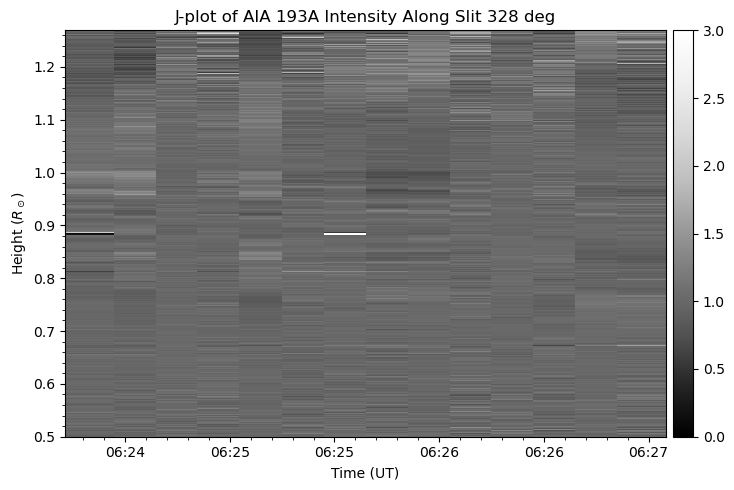

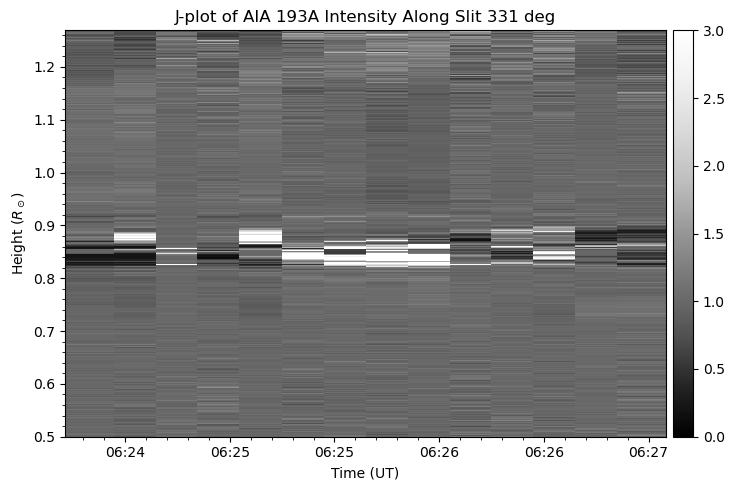

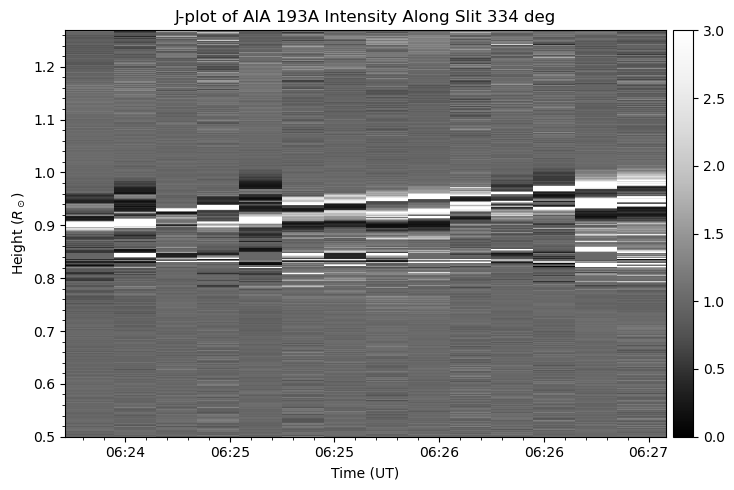

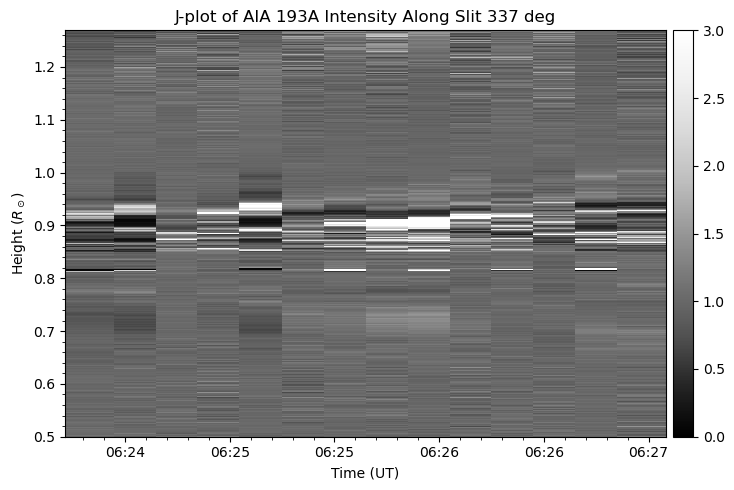

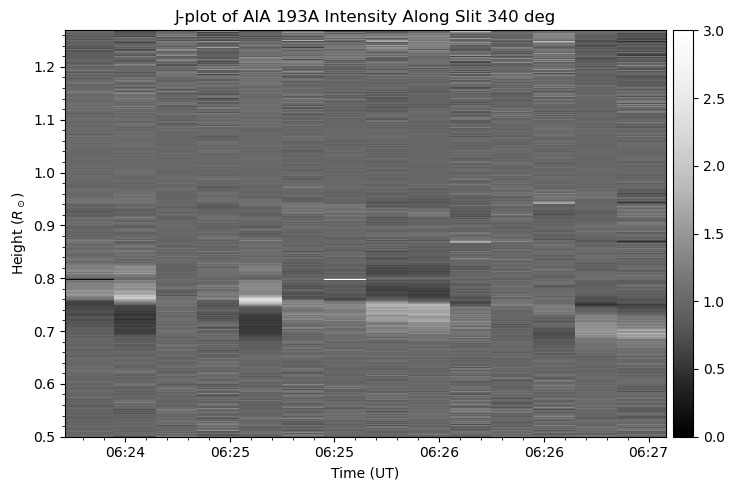

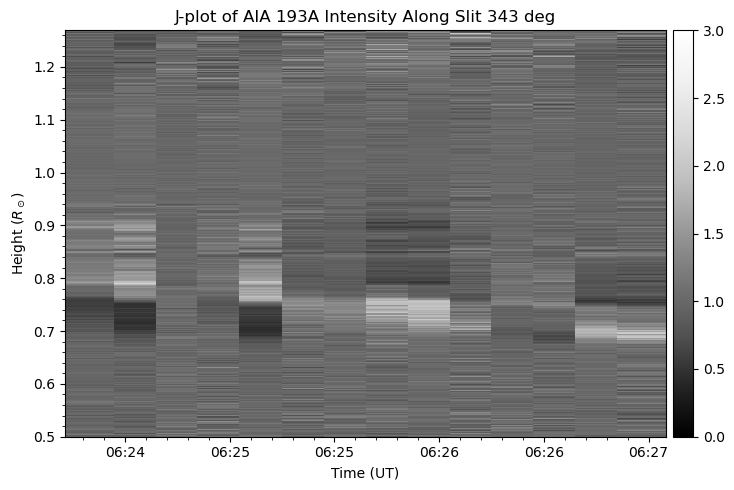

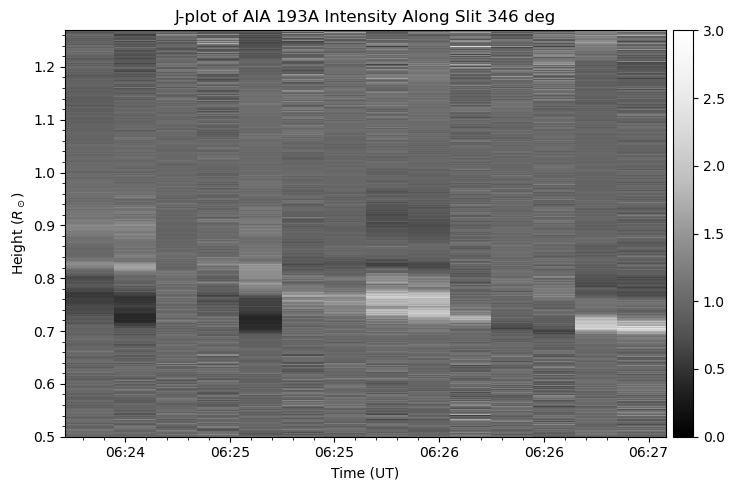

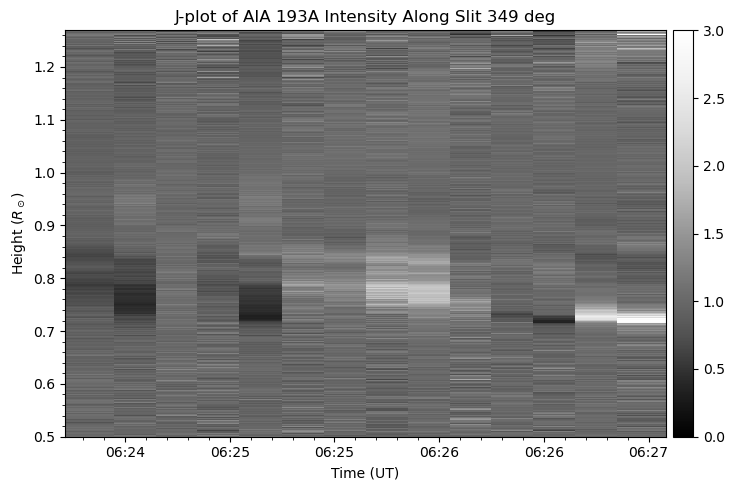

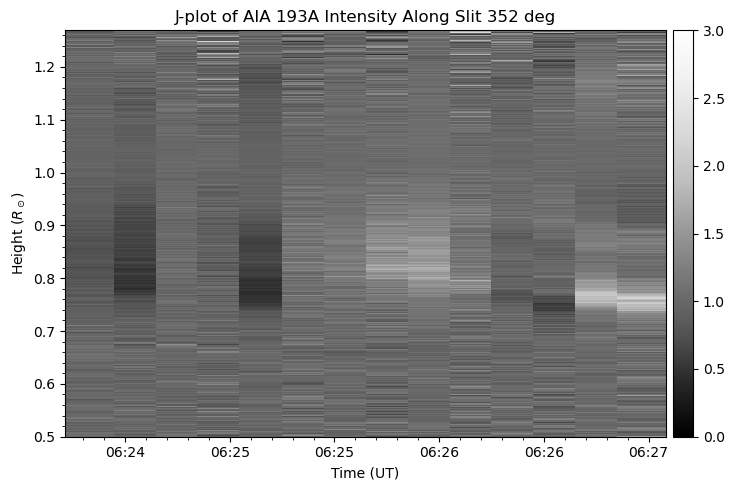

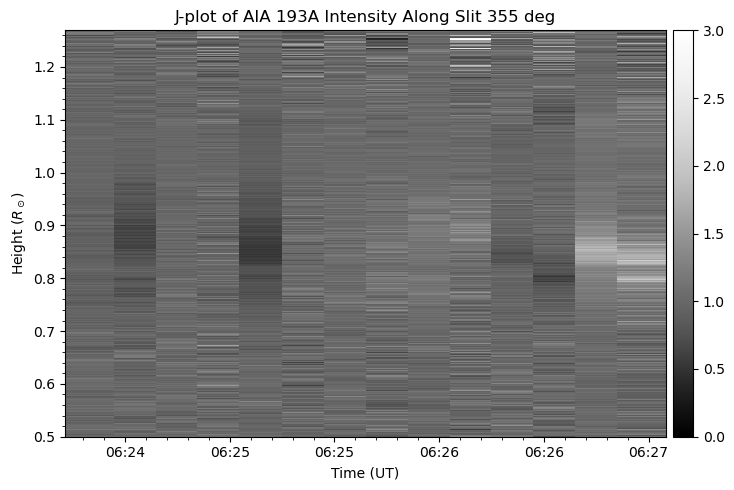

In [215]:
for angle in centered_list:

    height = output_obj[f'distances_{angle}deg'][0].copy()
    intens = output_obj[f'intensity_{angle}deg'][0].copy()

    # plot the j-map
    fig = plt.figure(figsize=[8,5])
    ax = fig.add_subplot(111)
    jmap = ax.pcolormesh(datenum_arr, height/m.rsun_obs.value, intens, vmin=0, vmax=3, cmap='Greys_r')
    plt.colorbar(jmap, ax=ax, pad=0.01)
    ax.set_xlabel('Time (UT)')
    ax.set_ylabel(r'Height ($R_\odot$)')
    ax.set_title(f"J-plot of {output_obj['instrument'][0]} Intensity Along Slit {angle} deg")
    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_minor_locator(AutoMinorLocator(n=5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(n=5))
    # ax.set_ylim(bottom=np.ceil(m.rsun_obs.value)) # round up to the nearest integer
    ax.set_ylim(bottom=0.5) # set the lower limit to 0.5 Rsun to focus on the region of interest
    fig.tight_layout()
    plt.show()